In [1]:
!pip install -q kagglehub scikit-image seaborn

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from skimage.feature import hog, local_binary_pattern, graycomatrix, graycoprops

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [3]:
import kagglehub

path = kagglehub.dataset_download(
    "paultimothymooney/chest-xray-pneumonia"
)

print("Dataset path:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset path: /kaggle/input/chest-xray-pneumonia


In [4]:
for root, dirs, files in os.walk(path):
    if "NORMAL" in dirs and "PNEUMONIA" in dirs:
        print("Dataset found at:", root)

Dataset found at: /kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val
Dataset found at: /kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/test
Dataset found at: /kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/train
Dataset found at: /kaggle/input/chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray/val
Dataset found at: /kaggle/input/chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray/test
Dataset found at: /kaggle/input/chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray/train
Dataset found at: /kaggle/input/chest-xray-pneumonia/chest_xray/val
Dataset found at: /kaggle/input/chest-xray-pneumonia/chest_xray/test
Dataset found at: /kaggle/input/chest-xray-pneumonia/chest_xray/train


In [5]:
dataset_dir = None

for root, dirs, files in os.walk(path):
    if "NORMAL" in dirs and "PNEUMONIA" in dirs:
        dataset_dir = root
        break

print(dataset_dir)

/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val


In [6]:
image_paths = []
labels = []

normal_dir = os.path.join(dataset_dir, "NORMAL")
pneumonia_dir = os.path.join(dataset_dir, "PNEUMONIA")

for file in os.listdir(normal_dir):
    if file.lower().endswith((".jpeg", ".jpg", ".png")):
        image_paths.append(os.path.join(normal_dir, file))
        labels.append(0)

for file in os.listdir(pneumonia_dir):
    if file.lower().endswith((".jpeg", ".jpg", ".png")):
        image_paths.append(os.path.join(pneumonia_dir, file))
        labels.append(1)

print("Total images:", len(image_paths))
print("Normal:", labels.count(0))
print("Pneumonia:", labels.count(1))

Total images: 16
Normal: 8
Pneumonia: 8


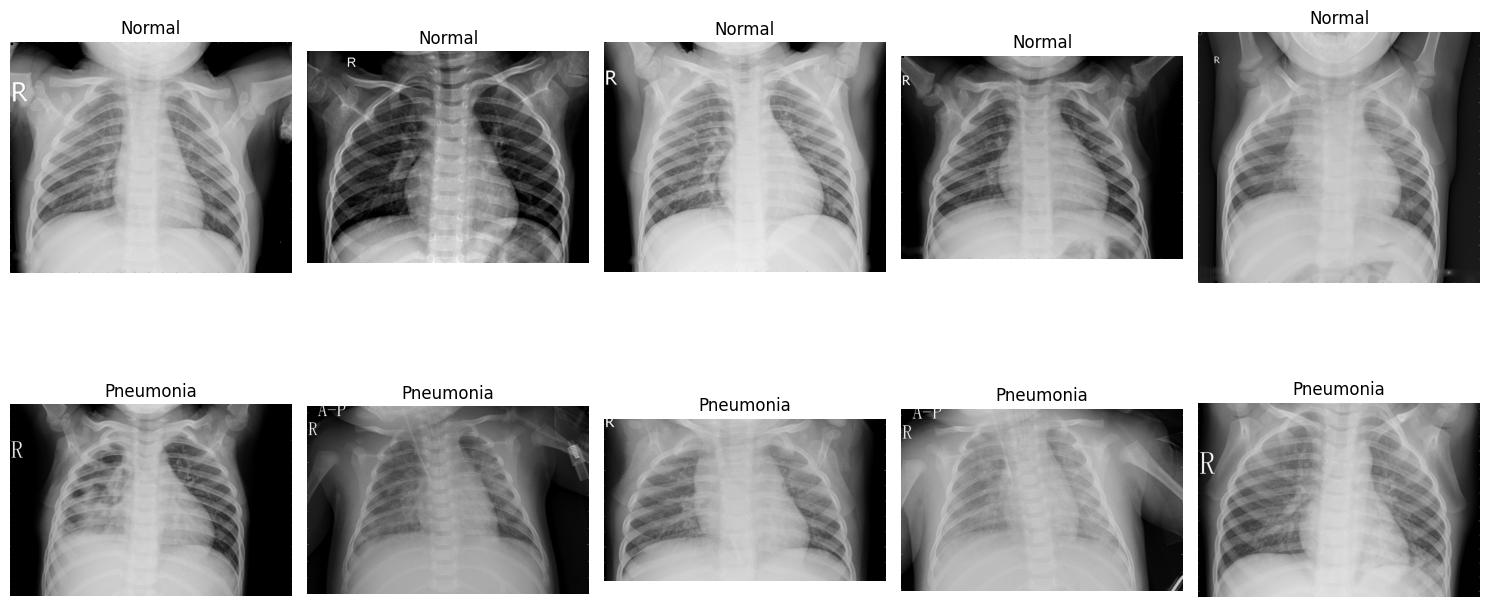

In [7]:
normal_images = [
    os.path.join(normal_dir, x)
    for x in os.listdir(normal_dir)
    if x.lower().endswith((".jpeg", ".jpg", ".png"))
]

pneumonia_images = [
    os.path.join(pneumonia_dir, x)
    for x in os.listdir(pneumonia_dir)
    if x.lower().endswith((".jpeg", ".jpg", ".png"))
]

plt.figure(figsize=(15, 8))

for i, img_path in enumerate(random.sample(normal_images, 5)):
    img = Image.open(img_path)

    plt.subplot(2, 5, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title("Normal")
    plt.axis("off")

for i, img_path in enumerate(random.sample(pneumonia_images, 5)):
    img = Image.open(img_path)

    plt.subplot(2, 5, i + 6)
    plt.imshow(img, cmap="gray")
    plt.title("Pneumonia")
    plt.axis("off")

plt.tight_layout()
plt.show()

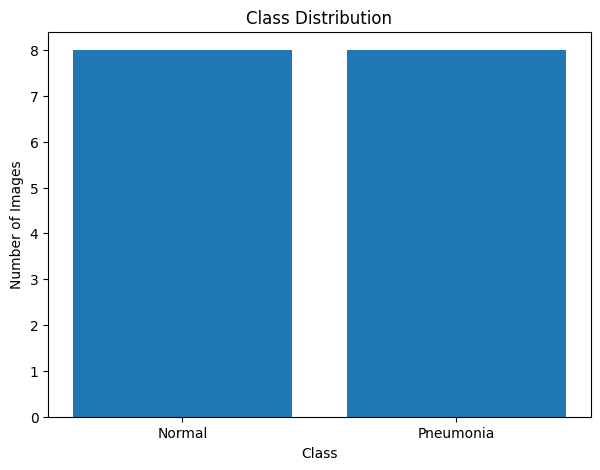

Class distribution:
Normal: 8
Pneumonia: 8


In [8]:
class_counts = pd.Series(labels).value_counts().sort_index()

class_names = ["Normal", "Pneumonia"]

plt.figure(figsize=(7, 5))

plt.bar(class_names, class_counts.values)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

print("Class distribution:")
print("Normal:", class_counts[0])
print("Pneumonia:", class_counts[1])

In [9]:
X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training images:", len(X_train))
print("Validation images:", len(X_val))
print("Testing images:", len(X_test))

Training images: 11
Validation images: 2
Testing images: 3


In [10]:
IMG_SIZE = 128

def load_image(path):
    img = Image.open(path).convert("L")
    img = img.resize((IMG_SIZE, IMG_SIZE))

    img = np.array(img, dtype=np.float32) / 255.0

    return img

In [11]:
def prepare_data(paths, labels):
    X = []

    for path in paths:
        img = load_image(path)
        X.append(img)

    X = np.array(X)
    X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

    y = np.array(labels)

    return X, y

In [12]:
X_train_data, y_train_data = prepare_data(X_train, y_train)

X_val_data, y_val_data = prepare_data(X_val, y_val)

X_test_data, y_test_data = prepare_data(X_test, y_test)

print("Training:", X_train_data.shape)
print("Validation:", X_val_data.shape)
print("Testing:", X_test_data.shape)

Training: (11, 128, 128, 1)
Validation: (2, 128, 128, 1)
Testing: (3, 128, 128, 1)


In [13]:
model = models.Sequential([

    layers.Input(shape=(128, 128, 1)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,193 (12.60 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [15]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train_data,
    y_train_data,
    validation_data=(X_val_data, y_val_data),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.4545 - loss: 0.7069 - val_accuracy: 0.5000 - val_loss: 0.7034
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 793ms/step - accuracy: 0.4545 - loss: 0.8027 - val_accuracy: 0.5000 - val_loss: 0.7069
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 824ms/step - accuracy: 0.7273 - loss: 0.6064 - val_accuracy: 0.5000 - val_loss: 0.7150
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 719ms/step - accuracy: 0.4545 - loss: 0.7383 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 998ms/step - accuracy: 0.5455 - loss: 0.6647 - val_accuracy: 0.5000 - val_loss: 0.6911
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - accuracy: 0.5455 - loss: 0.6740 - val_accuracy: 0.5000 - val_loss: 0.6900
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.6364 - loss: 0.6158 - val_accuracy: 0.5000 - val_loss: 0.6912
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 637ms/step - accuracy: 0.4545 - loss: 0.7095 - val_accuracy: 0.5000 - val_loss: 0.

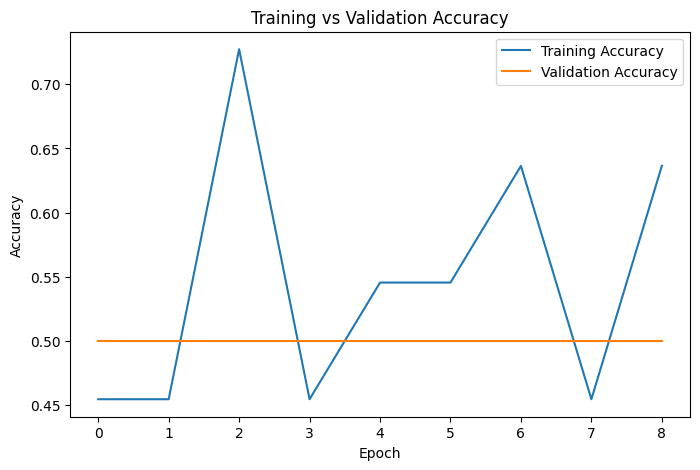

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.show()

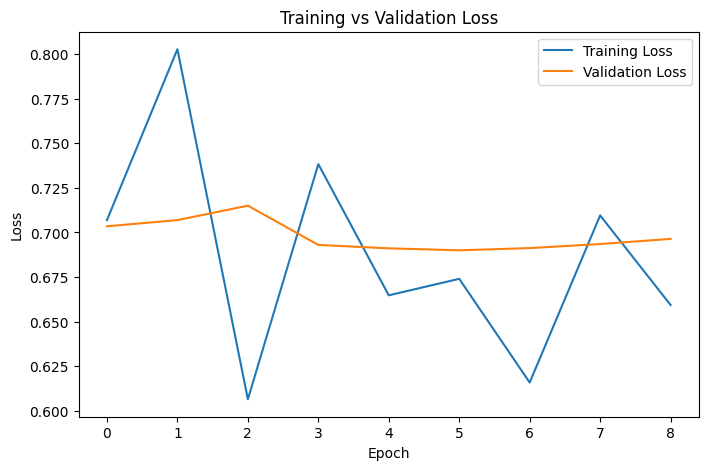

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

In [18]:
y_probability = model.predict(X_test_data)

y_probability = y_probability.ravel()

y_pred = (y_probability >= 0.5).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step


In [19]:
accuracy = accuracy_score(y_test_data, y_pred)

precision = precision_score(y_test_data, y_pred)

recall = recall_score(y_test_data, y_pred)

f1 = f1_score(y_test_data, y_pred)

auc = roc_auc_score(y_test_data, y_probability)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("AUROC    :", round(auc, 4))

Accuracy : 0.6667
Precision: 0.5
Recall   : 1.0
F1 Score : 0.6667
AUROC    : 0.5


In [20]:
print(
    classification_report(
        y_test_data,
        y_pred,
        target_names=["Normal", "Pneumonia"]
    )
)

              precision    recall  f1-score   support

      Normal       1.00      0.50      0.67         2
   Pneumonia       0.50      1.00      0.67         1

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



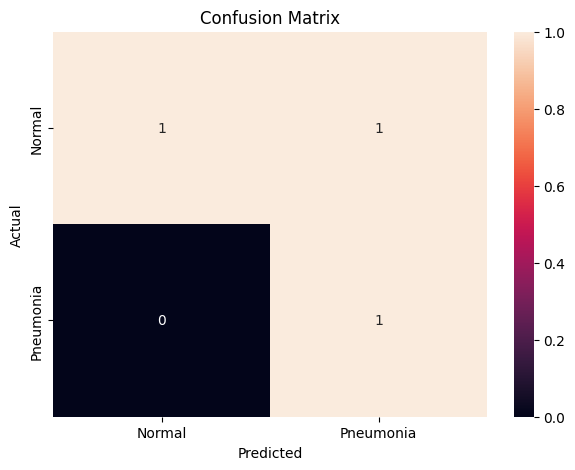

In [21]:
cm = confusion_matrix(y_test_data, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Normal", "Pneumonia"],
    yticklabels=["Normal", "Pneumonia"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [22]:
def extract_hog(img):
    feature = hog(
        img,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )

    return feature

In [23]:
sample_img = load_image(X_train[0])

hog_features = extract_hog(sample_img)

print("HOG feature length:", len(hog_features))

HOG feature length: 8100


In [24]:
def extract_lbp(img):

    img_uint8 = (img * 255).astype(np.uint8)

    radius = 1
    points = 8 * radius

    lbp = local_binary_pattern(
        img_uint8,
        points,
        radius,
        method="uniform"
    )

    hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, points + 3),
        range=(0, points + 2)
    )

    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-7)

    return hist

In [25]:
lbp_features = extract_lbp(sample_img)

print("LBP feature length:", len(lbp_features))

LBP feature length: 10


In [26]:
def extract_glcm(img):

    img_uint8 = (img * 255).astype(np.uint8)

    # Reduce gray levels to make GLCM smaller
    img_small = (img_uint8 // 32).astype(np.uint8)

    glcm = graycomatrix(
        img_small,
        distances=[1],
        angles=[0],
        levels=8,
        symmetric=True,
        normed=True
    )

    contrast = graycoprops(glcm, "contrast")[0, 0]
    dissimilarity = graycoprops(glcm, "dissimilarity")[0, 0]
    homogeneity = graycoprops(glcm, "homogeneity")[0, 0]
    energy = graycoprops(glcm, "energy")[0, 0]
    correlation = graycoprops(glcm, "correlation")[0, 0]

    return np.array([
        contrast,
        dissimilarity,
        homogeneity,
        energy,
        correlation
    ])

In [27]:
glcm_features = extract_glcm(sample_img)

print("GLCM features:")
print(glcm_features)

GLCM features:
[0.20041831 0.18011811 0.91197096 0.36563909 0.97643221]


In [28]:
def extract_all_features(path):

    img = load_image(path)

    hog_feature = extract_hog(img)

    lbp_feature = extract_lbp(img)

    glcm_feature = extract_glcm(img)

    combined = np.concatenate([
        hog_feature,
        lbp_feature,
        glcm_feature
    ])

    return combined

In [29]:
features = extract_all_features(X_train[0])

print("Total feature vector length:", len(features))

Total feature vector length: 8115


In [30]:
X_features = []

for i, path in enumerate(image_paths):

    feature = extract_all_features(path)

    X_features.append(feature)

    if (i + 1) % 500 == 0:
        print("Processed:", i + 1)

X_features = np.array(X_features)

y_features = np.array(labels)

print("Feature matrix shape:", X_features.shape)
print("Labels shape:", y_features.shape)

Feature matrix shape: (16, 8115)
Labels shape: (16,)


In [31]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "AUROC"
    ],
    "CNN": [
        accuracy,
        precision,
        recall,
        f1,
        auc
    ]
})

results["CNN"] = results["CNN"].round(4)

print(results)

      Metric     CNN
0   Accuracy  0.6667
1  Precision  0.5000
2     Recall  1.0000
3   F1 Score  0.6667
4      AUROC  0.5000
